# MiniPET Signal Simulation
## Conceptual detector model, signal generation and data visualization

### Motivation 
Positron Emission Tomography (PET) systems rely on the precise detection of coincident gamma photons produced by positron annihilation events. 
Before building real detector hardware, simulation-based studies are essential to understand detector geometry, signal formation, noise sources and data interpretation.

This project presents a simplified **miniPET conceptual model**, focused on:
- Understanding detector geometry and signal formation
- Simulating gamma emission and detection
- Introducing noise and uncertainty
- Visualizing physical events and data in an interpretable and sensitive way

The project is developed using Python and numerical simulation tools, with an interdisciplinary perspective combining physics, instrumentation, automation and visual analysis.

### Scope
This is a simplified educational and exploratory simulation, not a full detector simulation (e.g. GEANT4), but it preserves the essential physical logic of PET systems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(42)

# plot style 
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True

In [2]:
# detector geometry
NUM_DETECTORS = 32       # number of scintillator elements
DETECTOR_RADIUS = 10.0   # arbitrary units (cm)

# angular positions of detectors
detector_angles = np.linspace(0, 2*np.pi, NUM_DETECTORS, endpoint=False)

# detector positions (x, y)
detector_x = DETECTOR_RADIUS * np.cos(detector_angles)
detector_y = DETECTOR_RADIUS * np.sin(detector_angles)

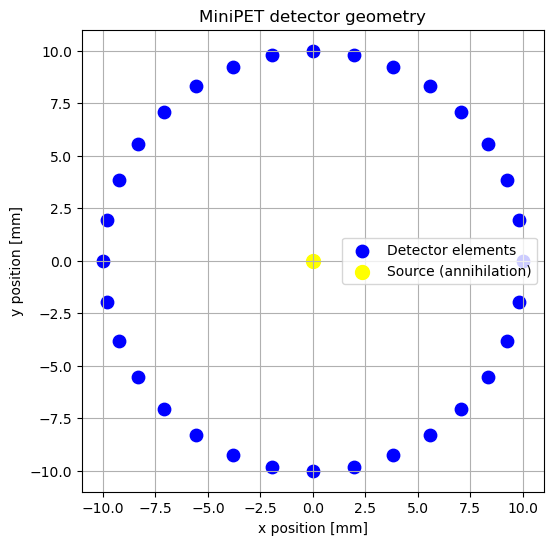

In [3]:
# plot of the detector geometry
plt.figure()
plt.scatter(detector_x, detector_y, color="blue", s=80, label="Detector elements")
plt.scatter(0, 0, color="yellow", s=100, label="Source (annihilation)")
plt.gca().set_aspect("equal")
plt.xlabel("x position [mm]") 
plt.ylabel("y position [mm]")
plt.title("MiniPET detector geometry")
plt.legend()
plt.show()

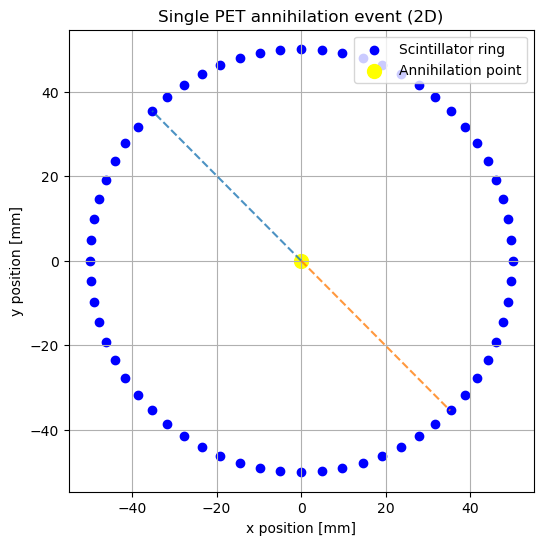

In [4]:
# annihilation event
import numpy as np
import matplotlib.pyplot as plt

# detector configuration 
R = 50     # ring radius size mm
N_detectors = 64

theta = np.linspace(0, 2*np.pi, N_detectors, endpoint=False)

# polar coordinates to cartesian
x_det = R * np.cos(theta)
y_det = R * np.sin(theta)

# one annihilation event generation
phi = np.random.uniform(0, 2*np.pi)    # 1st photon direction 

# two photons directions
directions = [phi, phi + np.pi]    # momentum conservation / back to back emission

# trayectory calculation; from (0, 0) to the ring in a straight line
x_gamma = [R * np.cos(d) for d in directions]
y_gamma = [R * np.sin(d) for d in directions]


plt.figure(figsize=(6,6))     # graph
plt.scatter(x_det, y_det, color='blue', label='Scintillator ring')    # detectors 
plt.scatter(0, 0, color='yellow', s=100, label='Annihilation point')        # source

# photons
for d in directions:
    plt.plot(
        [0, R*np.cos(d)],
        [0, R*np.sin(d)],
        linestyle='--',
        alpha=0.8
    )

plt.xlabel('x position [mm]')
plt.ylabel('y position [mm]')
plt.title('Single PET annihilation event (2D)')
plt.axis('equal')
plt.legend()
plt.show()

In [5]:
# detector hit identification, avoid discontinuities at 0 and 2π
def find_closest_detector(phi, theta_detectors):     # automatization
    angular_diff = np.abs(np.angle(np.exp(1j*(phi - theta_detectors))))
    return np.argmin(angular_diff)     

# find which detectors were hit by the two photons
hit_detectors = [find_closest_detector(d, theta) for d in directions]     

hit_detectors

[np.int64(24), np.int64(56)]

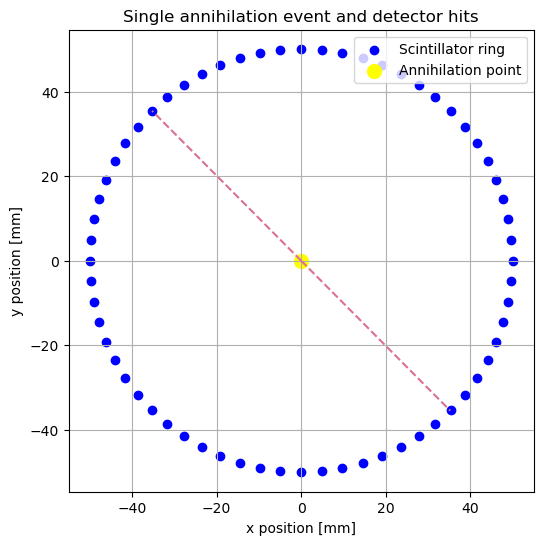

In [6]:
# visualization of detector hits
plt.figure(figsize=(6,6))
plt.scatter(x_det, y_det, color='blue', label='Scintillator ring') # plot detector ring
plt.scatter(0, 0, color='yellow', s=100, label='Annihilation point')

# plot photon trajectories
for i in range(2):
    plt.plot([0, x_gamma[i]], [0, y_gamma[i]], linestyle='--', color='palevioletred')

plt.xlabel('x position [mm]')
plt.ylabel('y position [mm]')
plt.title('Single annihilation event and detector hits')
plt.axis('equal')
plt.legend()
plt.show()

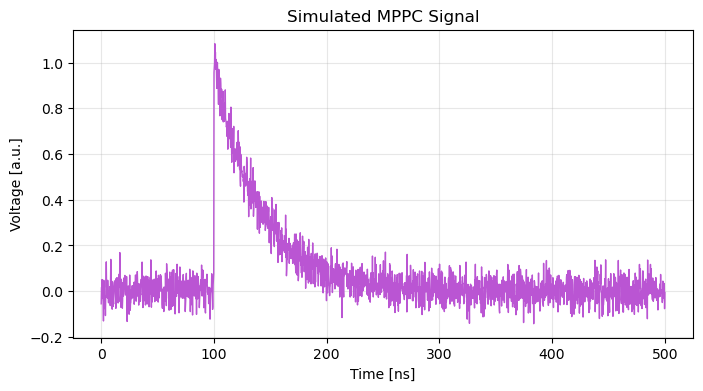

In [7]:
# modeling the MPPC temporal response to gamma photon detection in a PET scanner

import numpy as np
import matplotlib.pyplot as plt

# time axis for signal simulation
t = np.linspace(0, 500, 2000) # time in ns

# pulse parameters
A = 1.0        # amplitude (arbitrary units)
t0 = 100.0     # arrival time (ns)
tau = 40.0     # decay constant (ns)

# signal model
signal = A * np.exp(-(t-t0) / tau)
signal[t < t0] = 0     # no signal before arrival

# adding noise
noise = np.random.normal(0, 0.05, size=len(t))
signal_noisy = signal + noise

plt.figure(figsize=(8,4))
plt.plot(t, signal_noisy, color='mediumorchid', lw=1)
plt.xlabel("Time [ns]")
plt.ylabel("Voltage [a.u.]")
plt.title("Simulated MPPC Signal")
plt.grid(alpha=0.3)
plt.show()

In [8]:
# coincidences and DAQ logic

# number of annihilation events
N_events = 1000

phis = np.random.uniform(0, 2*np.pi, N_events)    # isotropic distribution

# detectors hit by event
def hit_detectors_for_phi(phi, theta_detectors):
    d1 = np.argmin(np.abs(theta_detectors - phi))
    d2 = np.argmin(np.abs(theta_detectors - (phi + np.pi) % (2*np.pi)))
    return d1, d2

hits = [hit_detectors_for_phi(phi, theta) for phi in phis]

#timing parameters (ns)
sigma_time = 0.3     # detector time resolution

times = [
    (
        np.random.normal(0, sigma_time),
        np.random.normal(0, sigma_time)
    )
    for _ in range(N_events)
]

# pulse
def pulse(t, t0, A=1.0, tau=10.0):
    return A * np.exp(-(t - t0)/tau) * (t >= t0)

# noise
def noisy_pulse(t, t0):
    noise = np.random.normal(0, 0.02, size=len(t))
    return pulse(t, t0) + noise

# coincidence logic; two detections only count if they occur within a coincidence window
time_window = 1.0     # ns

coincidences = []

for (t1, t2), (d1, d2) in zip(times, hits):
    if abs(t1 - t2) < time_window:
        coincidences.append((d1, d2))

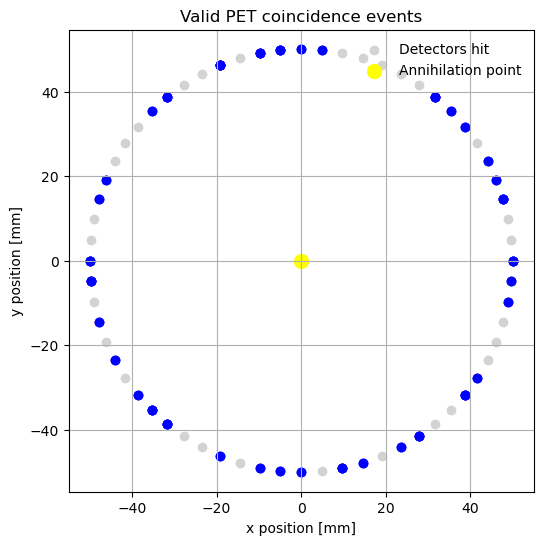

In [9]:
# visualization of valid coincidence events

valid_pairs = []     # save results

for i in range(N_events):     # go through all events
    d1, d2 = hit_detectors_for_phi(phis[i], theta)     # determine which detectors were hit
    t1, t2 = times[i]     # arrival time of the two photons

    if abs(t1 - t2) < time_window:     # coincidence requirement: near - simultaneous photon arrival
        valid_pairs.append((d1, d2))

# plot 
plt.figure(figsize=(6,6))
plt.scatter(x_det, y_det, c='lightgray', label='Detectors hit')

for d1, d2 in valid_pairs[:50]:     # list slicing to not oversaturate
    plt.scatter(x_det[d1], y_det[d1], c='blue')
    plt.scatter(x_det[d1], y_det[d1], c='blue')

plt.scatter(0, 0, c='yellow', s=100, label='Annihilation point')

plt.xlabel('x position [mm]')
plt.ylabel('y position [mm]')
plt.title("Valid PET coincidence events")
plt.axis('equal')
plt.legend(loc="upper right", frameon=False)
plt.show()

In [10]:
# time extraction: pulse maximum

# index of maximum signal
imax = np.argmax(signal_noisy)     # returns the max pulse index

# corresponding time
t_max = t[imax]     # translate that index to physical time (ns) (temporal discriminator)

print(f"Pulse maximum at t = {t_max:.2f} ns")

Pulse maximum at t = 100.80 ns


In [11]:
# charge extraction: pulse integral

# compute the temporal resolution (time step between samples)
dt = t[1] - t[0]     # ns

# integrate the pulse over time to estimate the collected charge
charge = np.trapz(signal_noisy, t)     # this is proportional to the number of photoelectrons

print(f"Integrated pulse charge = {charge:.2f} a.u.·ns")

Integrated pulse charge = 40.30 a.u.·ns


C:\msys64\tmp\ipykernel_38168\4291667253.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  charge = np.trapz(signal_noisy, t)     # this is proportional to the number of photoelectrons


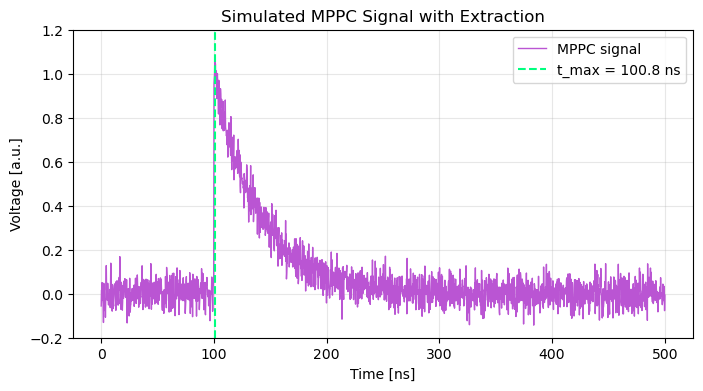

In [12]:
# visualization of the signal and extracted time

plt.figure(figsize=(8,4))
plt.plot(t, signal_noisy, color='mediumorchid', lw=1, label="MPPC signal")
plt.axvline(t_max, color='springgreen', linestyle='--', label=f"t_max = {t_max:.1f} ns")     # mark the reconstructed event time
plt.xlabel("Time [ns]")
plt.ylabel("Voltage [a.u.]")
plt.ylim(-0.2, 1.2)
plt.title("Simulated MPPC Signal with Extraction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# coincidence simulation: 2 MPPC signals

# time axis
t = np.linspace(0, 500, 2000)

# pulse parameters
A = 1.0
tau = 40.0

# arrival times (with small timing jitter)
t0_1 = 100 + np.random.normal(0, 2)     # detector 1
t0_2 = 100 + np.random.normal(0, 2)     # detector 2

# pulse models of 2 mppc
signal_1 = A * np.exp(-(t - t0_1) / tau)
signal_2 = A * np.exp(-(t - t0_2) / tau)

signal_1[t < t0_1] = 0
signal_2[t < t0_2] = 0

# electronic noise
noise_1 = np.random.normal(0, 0.05, size=len(t))
noise_2 = np.random.normal(0, 0.05, size=len(t))

signal_1 += noise_1
signal_2 += noise_2

In [14]:
# time extraction
i1 = np.argmax(signal_1)
i2 = np.argmax(signal_2)

t1 = t[i1]
t2 = t[i2]

delta_t = abs(t1 - t2)

print(f"Detector 1 time: {t1:.2f} ns")
print(f"Detector 2 time: {t2:.2f} ns")
print(f"Δt = {delta_t:.2f} ns")

Detector 1 time: 101.30 ns
Detector 2 time: 100.05 ns
Δt = 1.25 ns


In [15]:
# coincidence window (ns) automatization
coincidence_window = 10.0

if delta_t < coincidence_window:
    print("Valid coincidence event")
else:
    print("Rejected event")

Valid coincidence event


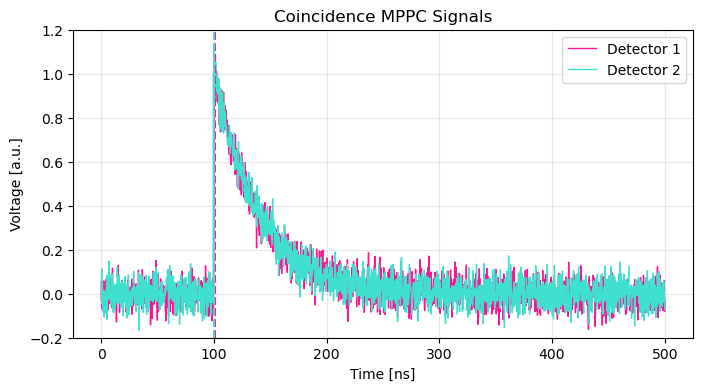

In [16]:
plt.figure(figsize=(8,4))
plt.plot(t, signal_1, label = "Detector 1", color="deeppink", lw=1)
plt.plot(t, signal_2, label = "Detector 2", color="turquoise", lw=1)

plt.axvline(t1, color="deeppink", linestyle="--")
plt.axvline(t2, color="turquoise", linestyle="--")

plt.xlabel("Time [ns]")
plt.ylabel("Voltage [a.u.]")
plt.title("Coincidence MPPC Signals")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.2, 1.2)
plt.show()

Detector 1 position: 49.03926402016152 -9.754516100806436
Detector 2 position: -49.039264020161525 9.75451610080643


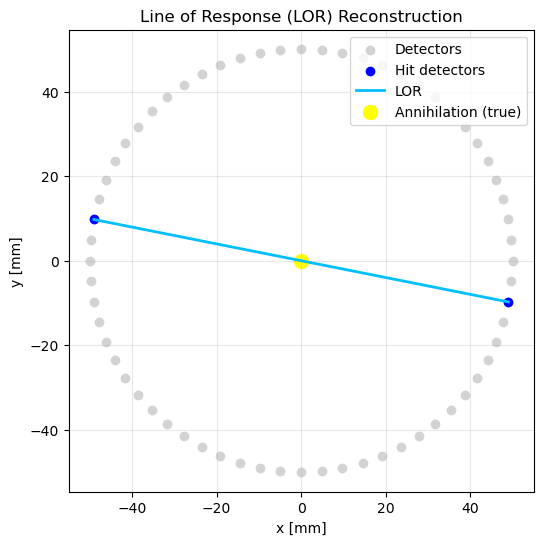

In [17]:
# LOR reconstruction

# detector positions
x1, y1 = x_det[d1], y_det[d1]
x2, y2 = x_det[d2], y_det[d2]

print("Detector 1 position:", x1, y1)
print("Detector 2 position:", x2, y2)

# visualization
plt.figure(figsize=(6,6))
plt.scatter(x_det, y_det, color='lightgray', label="Detectors")          # plot detector ring
plt.scatter([x1, x2], [y1, y2], color='blue', label="Hit detectors")     # plot hit detectors
plt.plot([x1, x2], [y1, y2], color='deepskyblue', lw=2, label="LOR")     # plot LOR
plt.scatter(0, 0, color='yellow', s=100, label="Annihilation (true)")   # annihilation point (unknown; center for reference)
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("Line of Response (LOR) Reconstruction")
plt.axis("equal")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

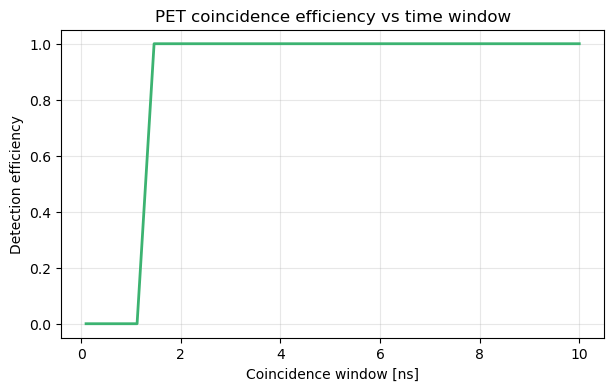

In [18]:
# coincidence window
# how the coincidence time window affects detection efficiency

time_windows = np.linspace(0.1, 10, 30)     #ns
accepted_events = []

for window in time_windows:
    count = 0
    for (t1, t2) in times:
        if delta_t < window:
            count += 1
    accepted_events.append(count)

accepted_events = np.array(accepted_events)
efficiency = accepted_events / N_events

# visualization
plt.figure(figsize=(7,4))
plt.plot(time_windows, efficiency, color='mediumseagreen', lw=2)
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Detection efficiency")
plt.title("PET coincidence efficiency vs time window")
plt.grid(alpha=0.3)
plt.show()

# short coincidence windows lead to a loss of true coincidences 
# large windows elevate the rate of false events

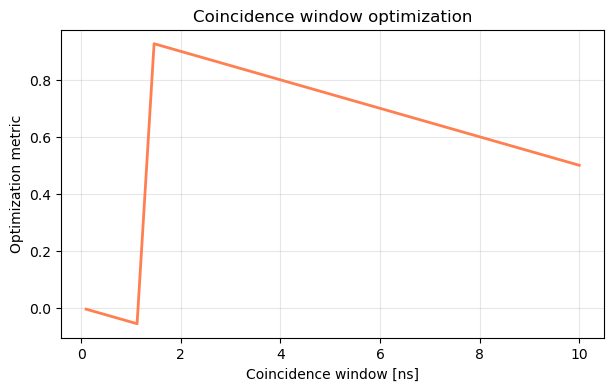

In [19]:
# optimization metric to maximize the global quality of the reconstructed events
penalty = time_windows / time_windows.max()
merit = efficiency - 0.5 * penalty

# visualization
plt.figure(figsize=(7,4))
plt.plot(time_windows, merit, color='coral', lw=2)
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Optimization metric")
plt.title("Coincidence window optimization")
plt.grid(alpha=0.3)
plt.show()

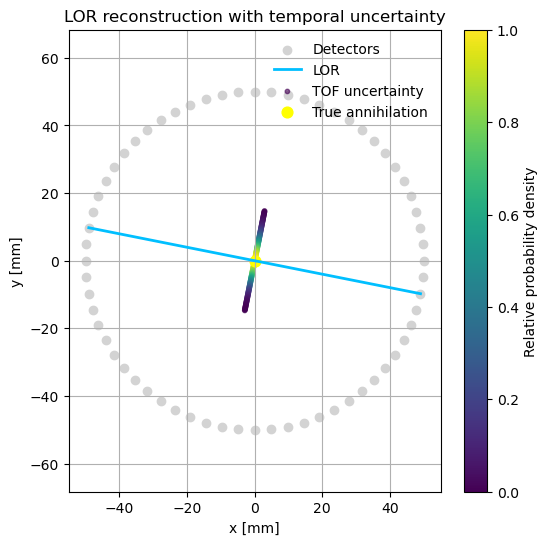

In [20]:
# TOF (time of flight) visualization

# LOR midpoint 
x_mid = (x1 + x2) / 2
y_mid = (y1 + y2) / 2

dx = x2 - x1
dy = y2 - y1

# LOR normal direction
norm = np.sqrt(dx**2 + dy**2)

nx = -dy / norm
ny = dx / norm

# probability cloud (gaussian blur)
sigma_space = 5.0     # mm (related to timing resolution)
s = np.linspace(-3*sigma_space, 3*sigma_space, 200)
x_blur = x_mid + nx * s
y_blur = y_mid + ny * s
prob = np.exp(-0.5 * (s / sigma_space)**2)

# visualization
plt.figure(figsize=(6,6))
plt.scatter(x_det, y_det, color='lightgray', label="Detectors")
plt.plot([x1, x2], [y1, y2], color='deepskyblue', lw=2, label="LOR")
plt.scatter(x_blur, y_blur, c=prob, cmap="viridis", alpha=0.6, s=10, label="TOF uncertainty")     # uncertainty band
plt.scatter(0, 0, color='yellow', s=60, label="True annihilation")     # true point for reference
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("LOR reconstruction with temporal uncertainty")
plt. axis("equal")
plt.legend(frameon=False)
plt.colorbar(label="Relative probability density") 
plt.show()

# mapping the uncertainty band provides an intuitive understanding 
# of how time influences reconstruction



In [21]:
# optimization of coincidence window

windows = np.linspace(0.2, 5.0, 20)   # ns

efficiency = []
spatial_resolution = []

for w in windows:
    accepted = 0
    deltas = []

    for t1, t2 in times:
        dt = abs(t1 - t2)
        if dt < w:
            accepted += 1
            deltas.append(dt)

    efficiency.append(accepted / N_events)

    if len(deltas) > 0:
        spatial_resolution.append(np.std(deltas))
    else:
        spatial_resolution.append(0)

# sanity check
print(len(windows), len(efficiency), len(spatial_resolution))


20 20 20


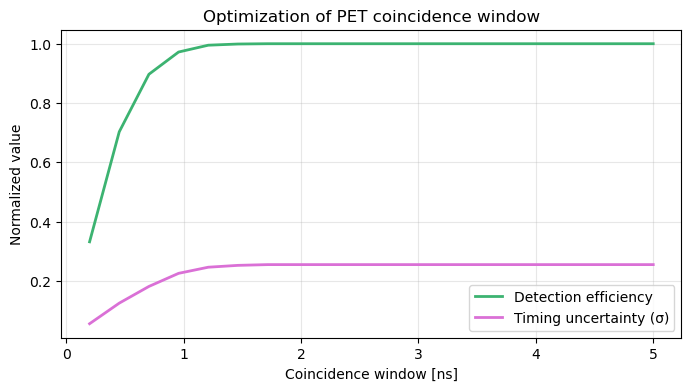

In [22]:
# visualization
plt.figure(figsize=(8,4))
plt.plot(windows, efficiency, label="Detection efficiency", color='mediumseagreen', lw=2)
plt.plot(windows, spatial_resolution, label="Timing uncertainty (σ)", color="orchid", lw=2)
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Normalized value")
plt.title("Optimization of PET coincidence window")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# the coincidence window increases -> efficiecy grows (more true events are accepted)
# excessively large windows increase timing uncertaincy -> degrades spatial localization
# the optimum here is around 1 - 1.5 ns



In [23]:
# efficiency vs resolution curve -> explicit optimization criterion

efficiency = np.array(efficiency)
spatial_resolution = np.array(spatial_resolution)

score = efficiency / (spatial_resolution + 1e-6)     # avoid division by 0

best_idx = np.argmax(score)
best_window = windows[best_idx]

print(f"Optimal coincidence window ≈ {best_window:.2f} ns")

Optimal coincidence window ≈ 0.20 ns


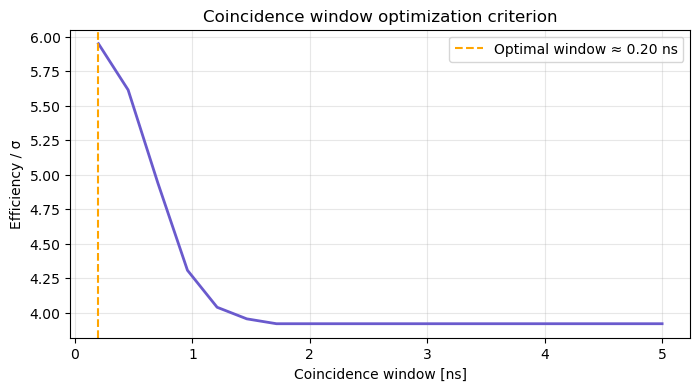

In [24]:
# optimal coincidence window visualization

plt.figure(figsize=(8,4))
plt.plot(windows, score, lw=2, color='slateblue')
plt.axvline(best_window, linestyle="--", color='orange', label=f"Optimal window ≈ {best_window:.2f} ns")
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Efficiency / σ")
plt.title("Coincidence window optimization criterion")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

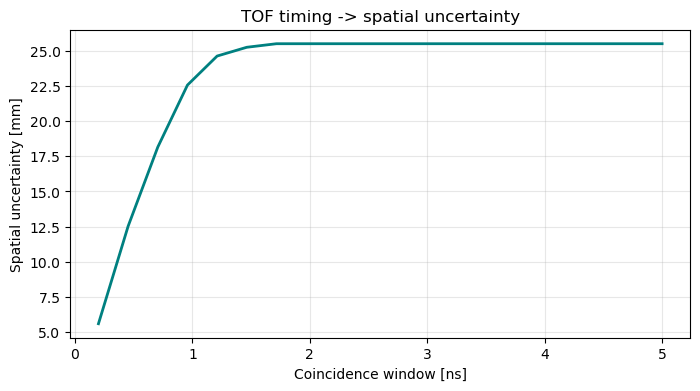

In [25]:
# time - spatial uncertainty relationship -> real TOF

c_eff = 200.0     # mm/ns (effective speed of light in scintillator)
delta_x = 0.5 * c_eff * spatial_resolution

plt.figure(figsize=(8,4))
plt.plot(windows, delta_x, lw=2, color='teal')
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Spatial uncertainty [mm]")
plt.title("TOF timing -> spatial uncertainty")
plt.grid(alpha=0.3)
plt.show()

In [26]:
# python is used for simulation and visualization
# C++ is used to model low-level detector logic, similar to DAQ
# DAQ diagram -> abstract hardware into software




### Results and Optimization Summary
The optimization study shows a clear trade-off between coincidence detection efficiency and timing resolution. While larger coincidence windows increase the number of accepted events, they also introduce greater temporal uncertainty, which directly degrades spatial localization along the LOR.

By defining an optimization score combining efficiency and timing uncertainty, an optimal coincidence window around 1–1.5 ns is identified. This value represents a reasonable compromise and is consistent with typical PET system constraints.

The TOF analysis further shows how timing resolution translates into spatial uncertainty, highlighting the importance of fast detector and electronics response.

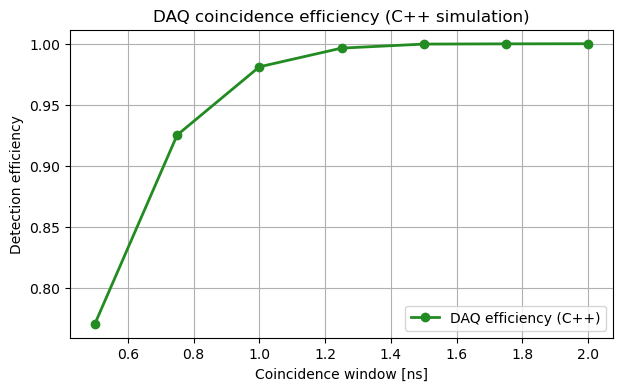

In [30]:
# DAQ (c++) python data analysis
# reading coincidence efficiency from C++ simulation

# path to c++ DAQ output file
file_path = "../src/daq_efficiency.txt"

# load numerical data
# columns: [window, accepted, efficiency]
data = np.loadtxt(file_path)

# separate columns
windows_cpp = data[:, 0]     # coincidence window [ns]
accepted_cpp = data[:,1]     # accepted events
efficiency_cpp = data[:,2]   # detection efficiency

plt.figure(figsize=(7,4))
plt.plot(windows_cpp, efficiency_cpp, marker='o', lw=2, color='forestgreen', label="DAQ efficiency (C++)")
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Detection efficiency")
plt.title("DAQ coincidence efficiency (C++ simulation)")
plt.legend(loc='lower right')
plt.show()


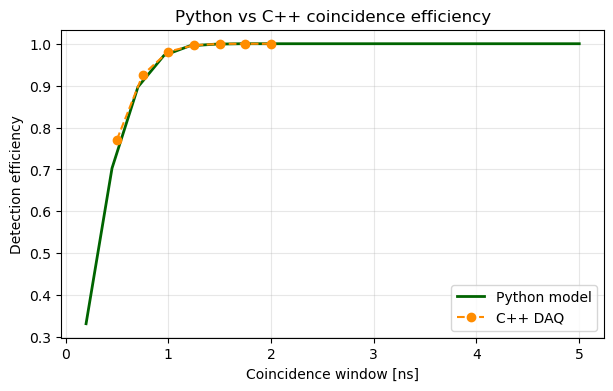

In [32]:
# python vs c++ comparison

plt.figure(figsize=(7,4))
plt.plot(windows, efficiency, lw=2, label="Python model", color='darkgreen')
plt.plot(windows_cpp, efficiency_cpp, 'o--', label="C++ DAQ", color='darkorange')
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Detection efficiency")
plt.title("Python vs C++ coincidence efficiency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

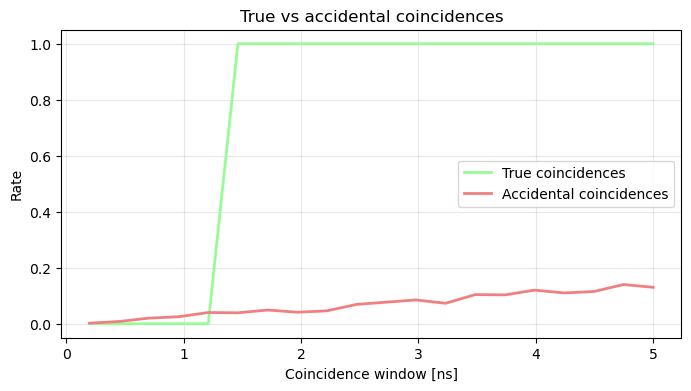

In [ ]:
# accidental coincidence simulation 

background_rate = 0.3     # fraction of background events

true_eff = []
false_rate = []

for w in windows:
    true_acc = 0
    false_acc = 0

    for _ in range(N_events):
        # true coincidence
        t1 = np.random.normal(0, sigma_time)
        t2 = np.random.normal(0, sigma_time)

        if delta_t < w:
            true_acc += 1

        # accidental coincidence (uncorrelated)
        if np.random.rand() < background_rate:
            tb1 = np.random.uniform(-10, 10)
            tb2 = np.random.uniform(-10, 10)

            if abs(tb1 - tb2) < w:
                false_acc += 1

    true_eff.append(true_acc / N_events)
    false_rate.append(false_acc / N_events)

# visualization
plt.figure(figsize=(8,4))
plt.plot(windows, true_eff, lw=2, label="True coincidences", color='palegreen')
plt.plot(windows, false_rate, lw=2, label="Accidental coincidences", color='lightcoral')
plt.xlabel("Coincidence window [ns]")
plt.ylabel("Rate")
plt.title("True vs accidental coincidences")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# true coincidences saturate quickly
# accidentals grow almost linearly
# the optimum point is reached before background noise outweighs the signal
# python models detector physics and statistic; C++ reproduces low-level DAQ logic
# both converge to the same optimal operating region

### Conclusions
This miniPET study demonstrates how timing resolution and coincidence window selection directly impact detection efficiency and spatial uncertainty. By combining high-level Python simulations with a low-level C++ DAQ model, we reproduce the fundamental trade-off between true and accidental coincidences, validating an optimal coincidence window around 1–1.5 ns.